Predictive Modeling Objectives

The objective of this notebook is to develop a predicive model capable of estimating a user's carbon footprint while useing behavioral factors that contribute most strongly to carbon impact. This notebook also explores carbon footprint predcition with regression and clustering to identify groups of users with similar behavioral patterns.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

Regression Footprint Prediction

In [2]:
model = LinearRegression()

df = pd.read_csv('../data/personal_carbon_footprint_behavior.csv')
df_dummies = df.copy()
df_dummies = df_dummies.drop(columns=('user_id'))
df_dummies = pd.get_dummies(df_dummies, dtype=int)

model = model.fit(df_dummies[["distance_km", "electricity_kwh", "renewable_usage_pct", "screen_time_hours",
                              "waste_generated_kg", "eco_actions", "day_type_Weekday", "day_type_Weekend",
                              "transport_mode_Bike", "transport_mode_Bus", "transport_mode_Car", "transport_mode_EV",
                              "transport_mode_Walk", "food_type_Mixed", "food_type_Non-Veg", "food_type_Veg",
                              "carbon_impact_level_High", "carbon_impact_level_Low", "carbon_impact_level_Medium"]],df_dummies[["carbon_footprint_kg"]])


sample_data = pd.DataFrame(df_dummies.drop(columns=('carbon_footprint_kg')))
sample_data["Footprint Prediction"] = model.predict(sample_data)
sample_data["Footprint Prediction"]

0       11.461959
1        7.958977
2        7.413263
3       11.692557
4        6.175018
          ...    
1395     4.751787
1396     6.331551
1397     7.954302
1398     5.666768
1399     8.315402
Name: Footprint Prediction, Length: 1400, dtype: float64

Train-Test Split

Here, the data is divided into testing and training sets to show how the model predicts unseen data.

In [33]:
X = df_dummies.drop('carbon_footprint_kg', axis=1)
y = df_dummies['carbon_footprint_kg']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [34]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse**(1/2)
r2 = r2_score(y_test, y_pred)

print('RMSE value: ',rmse)
print('R-squared value: ',r2)

RMSE value:  0.5567066912212919
R-squared value:  0.95892164099139


Strength Variables

Here, the model has produced an extremely strong R-squared of 0.95 and an RMSE of 0.55 kg of carbon. This model is very strong. This high R-squared suggests that the behavioral variables explain a large chunk of the carbon footprint.

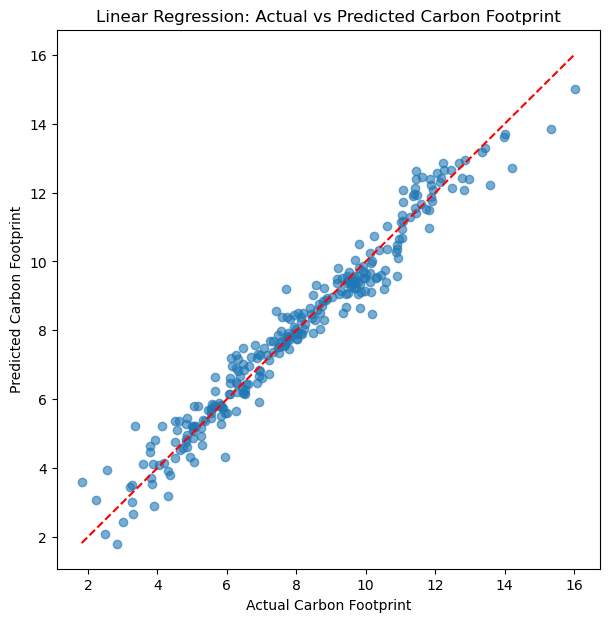

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red",linestyle="--")

plt.xlabel("Actual Carbon Footprint")
plt.ylabel("Predicted Carbon Footprint")
plt.title("Linear Regression: Actual vs Predicted Carbon Footprint")

plt.show()

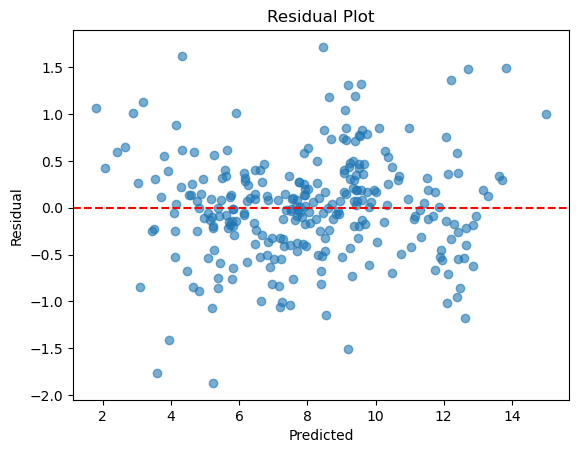

In [36]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

The residuals represented show the difference betweem the observed and predicted carbon footprints. Since the distribution is random, the models shows that there is no failure to account for varaince and that the linear model above is appropriate for this situation.

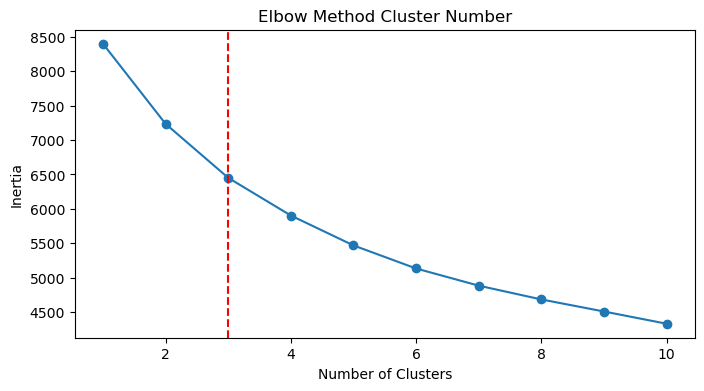

In [37]:

behaviors = df[['distance_km','electricity_kwh','renewable_usage_pct','screen_time_hours','waste_generated_kg','eco_actions']].copy()

scaler = StandardScaler()
#Scale the data so that unlike data in much larger values will not dominate the calculations
scaled_behaviors = scaler.fit_transform(behaviors)

#let's see how MANY clusters we need using the Elbow Method

sse_test = []

for k in range(1,11):
    kmeans = KMeans(init='random', n_clusters=k, n_init=10,random_state=42)
    kmeans.fit(scaled_behaviors)
    sse_test.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.title('Elbow Method Cluster Number')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.plot(range(1,11), sse_test, marker='o')
plt.axvline(3, linestyle='--', color='red')
plt.show()

Elbow Method Cluster Plot

The graph shows an "elbow" at k=3, a justification that any more clusters greater than three would yield less information and that there are mainly three clusters that have the most variation.

In [38]:
kmeans = KMeans(init='random', n_clusters=3, n_init=10,random_state=42)
behaviors['cluster'] = kmeans.fit_predict(scaled_behaviors)

cluster_group = behaviors.groupby('cluster').mean()
cluster_group_r = cluster_group.rename(index={0:'Lesser Consumers (Cluster 0)', 1 :'Large Consumers (Cluster 1)', 2 : 'Renewable Consumers (Cluster 2)'})
cluster_group_r

,distance_km,electricity_kwh,renewable_usage_pct,screen_time_hours,waste_generated_kg,eco_actions
cluster,,,,,,
Lesser Consumers (Cluster 0),8.817140,4.707179,16.913215,6.086982,0.548323,0.820513
Large Consumers (Cluster 1),9.139162,7.275460,14.775051,5.097137,0.873436,1.310838
Renewable Consumers (Cluster 2),9.428614,5.910347,70.358911,5.326485,0.691510,1.349010


The cluster groups with k=3 found in the Elbow Method are shows above with mean values. Based on those values, they have been converted into Lesser, Large, and Renewable Consumers groups.

Below, the notebook examins clustering. Clustering takes the data uses unsupervised machine learning to organize it into distinct groups naturally. There is no target, unlike the regression and classificatoin above.

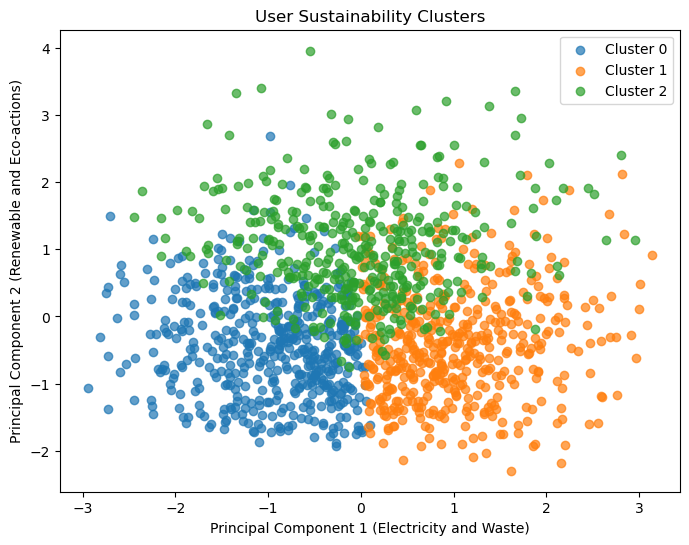

In [39]:

pca = PCA(n_components=2)

components = pca.fit_transform(scaled_behaviors)

behaviors['PC1'] = components[:,0]
behaviors['PC2'] = components[:,1]

plt.figure(figsize=(8,6))

for c in sorted(behaviors['cluster'].unique()):
    subset = behaviors[behaviors['cluster']==c]

    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=f'Cluster {c}',
        alpha=0.7
    )

plt.xlabel("Principal Component 1 (Electricity and Waste)")
plt.ylabel("Principal Component 2 (Renewable and Eco-actions)")
plt.title("User Sustainability Clusters")

plt.legend()

plt.show()

Cluster 0: Lesser Consumers, Cluster 1: Larger Consumers, Cluster 2: Renewable Consumers

In [40]:
behaviors2 = ['distance_km','electricity_kwh','renewable_usage_pct','screen_time_hours','waste_generated_kg','eco_actions']

PCA_meaning = pd.DataFrame(pca.components_.T,index=behaviors2, columns=['PC1', 'PC2'])
print(PCA_meaning.round(3))

                       PC1    PC2
distance_km          0.058  0.091
electricity_kwh      0.670 -0.085
renewable_usage_pct -0.016  0.678
screen_time_hours   -0.243 -0.187
waste_generated_kg   0.671 -0.172
eco_actions          0.195  0.678


PC1 Appears to be largely connected with electricty usage and waste generated, while PC2 largely tackes renewable ernergy and eco actions

Random Forest Regression

The Random Forest combines many trees to improve prediction accuracy, specifically good at predicting nonlinear relationships.

In [41]:

X = df_dummies.drop('carbon_footprint_kg', axis=1)
y = df_dummies['carbon_footprint_kg']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

forest = RandomForestRegressor(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

forest_prediction = forest.predict(X_test)

In [42]:
mse = mean_squared_error(y_test, forest_prediction)
rmse_f = mse**(1/2)
r2_f = r2_score(y_test, forest_prediction)

print('RMSE value: ',rmse_f)
print('R-squared value: ',r2_f)

RMSE value:  0.6701979726969802
R-squared value:  0.9404658135542461


In [43]:
values = {'Metric': ['RMSE', 'R-squared'], 'Linear Regression': [rmse, r2], 'Random Forest': [rmse_f, r2_f]}

estimation_table = pd.DataFrame(values)
estimation_table

,Metric,Linear Regression,Random Forest
0,RMSE,0.556707,0.670198
1,R-squared,0.958922,0.940466


Results

Based on the results above, the linear regression is a better fit for this scenario, with a better R-squared and smaller RMSE. Both models work very well, however, the situation is likely more fit to a linear explanation.

Classification Modeling

In [45]:
y = df['carbon_impact_level']
X = df_dummies.drop(columns=["carbon_footprint_kg","carbon_impact_level_High", 'carbon_impact_level_Low', 'carbon_impact_level_Medium'])

X_train, X_test, y_train, y_test_lr = train_test_split(X, y,test_size=0.2,random_state=42)

log_class = LogisticRegression(max_iter=1000)
log_class.fit(X_train, y_train)

predict = log_class.predict(X_test)

In [46]:
print(classification_report(y_test_lr,predict))

              precision    recall  f1-score   support

        High       0.89      0.85      0.87        46
         Low       0.89      0.85      0.87        73
      Medium       0.89      0.92      0.91       161

    accuracy                           0.89       280
   macro avg       0.89      0.87      0.88       280
weighted avg       0.89      0.89      0.89       280



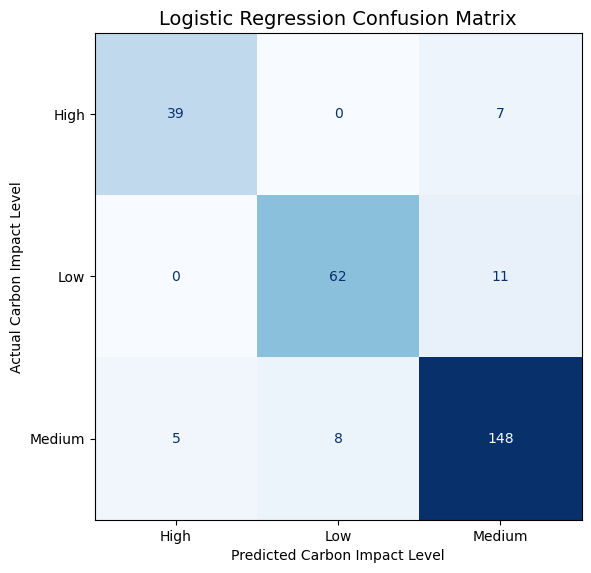

In [47]:
labels = log_class.classes_

matrix = confusion_matrix(y_test_lr, predict)
show = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)

#show.plot(cmap='Blues')
#plt.title('Logistic Regression Confusion Matrix')
fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=log_class.classes_
).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Logistic Regression Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Carbon Impact Level")
plt.ylabel("Actual Carbon Impact Level")
plt.tight_layout()
plt.show()

Carbon Low, Medium, High Carbon Impact Classification Matrix

This matrix shows my model's accuracy in predicting the impact level based on the real impact level of the user in the dataset. The mode more rarely predicted incorrect values on the edges, leading to predicting low when medium and medium when high. The diagonal values are the correctly predicted severity levels. Overall, the model correctly predicted 249/280. The best predictor being medium-medium, worst being high-high.

In [48]:
forest_classifiers = RandomForestClassifier(n_estimators=500, random_state=42)

forest_classifiers.fit(X_train, y_train)

forest_classifiers.feature_importances_

array([0.08814265, 0.23427869, 0.22503625, 0.07118724, 0.08602414,
       0.04207768, 0.00989121, 0.00951699, 0.01214256, 0.01160398,
       0.03209292, 0.01061621, 0.01281742, 0.02457178, 0.06837332,
       0.06162695])

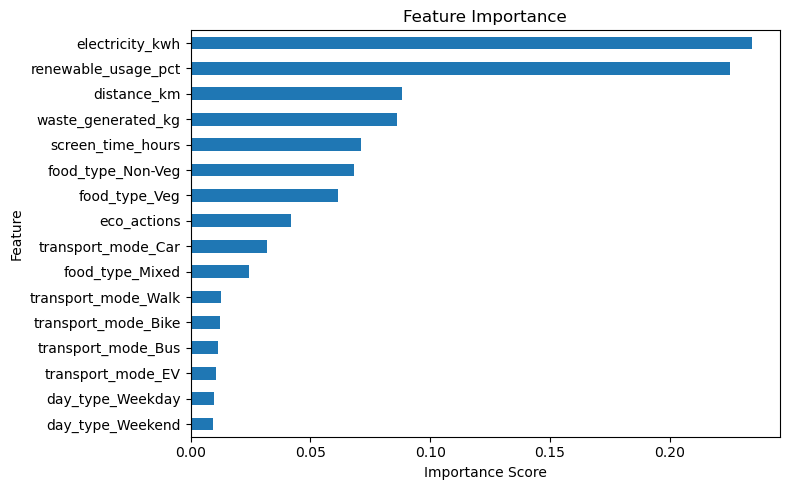

In [49]:
importance = pd.Series(forest_classifiers.feature_importances_,index=X.columns) 
importance.sort_values().plot.barh(figsize=(8,5))

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Feature Importance

The bar graph above showcases the contribution of each behavior and variable used to train the Forest Classifier.


Modeling Summary

Key findings
- Regression model accurately preducts a user's carbon footprint.
- Cluster methods reveal three distinct groups of users based on behavioral patterns.
- Impact levels can be accurately identified with classification modeling.
- Feature importance showcases electricity and renewable energy usage, along with distance and waste as important predictors.
